# Empirical Tests — Epic Giveaway → Steam Engagement

Implements and compares the staggered DiD strategies described in the writeup.

**Sections:**
1. Data loading and preparation
2. Descriptive statistics
3. TWFE event study (`pyfixest.feols` with `i(k_clip, ref=-1)`)
4. Pre-trend F-test (Wald test on pre-period coefficients)
5. Estimator comparison: TWFE vs. LP-DiD vs. did2s
6. Separated specification (first-giveaway effect vs. repeat-giveaway effect)
7. Cohort-level ATTs (Callaway–Sant'Anna style, not-yet-treated controls)

All figures → `../output/`.

**Packages:** `pyfixest 0.40`, `scipy 1.15`, `statsmodels 0.14`, `numpy`, `pandas`, `matplotlib`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2 as chi2_dist, norm as norm_dist
import pyfixest as pf
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR   = Path('../raw_data')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

PANEL_CSV = DATA_DIR / 'steamcharts' / 'all_monthly.csv'
K_MIN, K_MAX = -12, 12
K_REF        = -1

## 1. Data loading and preparation

In [2]:
df = pd.read_csv(PANEL_CSV, parse_dates=['month', 'first_giveaway_date'])

# Outcome
df['ln_avg'] = np.log1p(df['avg_players'])

# Relative event time k
df['k'] = (
    (df['month'].dt.year  - df['first_giveaway_date'].dt.year)  * 12 +
    (df['month'].dt.month - df['first_giveaway_date'].dt.month)
)

# ── Event-study sample: full-window games only, hard-trimmed (no clipping) ──
# Clipping (k.clip) would stuff all obs outside the window into the boundary
# bins, biasing k=K_MIN and k=K_MAX estimates. Instead we drop rows outside
# the window entirely. We also restrict to games that have observations for
# every month in [K_MIN, K_MAX] so the composition of the k-bin sample is
# constant across the pre-period (prevents spurious pre-trends from changing
# sample composition).
_game_months  = df.groupby('appid')['month'].apply(set)
_game_treat   = (df.groupby('appid')['first_giveaway_date']
                   .first()
                   .apply(lambda d: d.replace(day=1)))
_full_window_games = {
    appid
    for appid, treat_mo in _game_treat.items()
    if {treat_mo + pd.DateOffset(months=k) for k in range(K_MIN, K_MAX + 1)}
       .issubset(_game_months[appid])
}
print(f'Games with full [{K_MIN},{K_MAX}] window: {len(_full_window_games)}')

# Calendar-time identifiers in YYYYMM format (required by pyfixest.did)
df['t_ym'] = df['month'].dt.year * 100 + df['month'].dt.month
df['g_ym'] = (df['first_giveaway_date'].dt.year * 100
              + df['first_giveaway_date'].dt.month)

# Treatment cohort (year-quarter of first giveaway)
df['cohort_q'] = df['first_giveaway_date'].dt.to_period('Q').astype(str)

# Sequential month index (0 = Jul 2012, the earliest panel month)
# Required for pyfixest.lpdid which computes period differences directly
_base_y, _base_m = 2012, 7
df['t_seq'] = (df['month'].dt.year - _base_y) * 12 + (df['month'].dt.month - _base_m)
df['g_seq']  = ((df['first_giveaway_date'].dt.year - _base_y) * 12
                + (df['first_giveaway_date'].dt.month - _base_m))

# k_clip: used in all TWFE regressions (standard event-study boundary approach).
# Obs with k < K_MIN are coded as k=K_MIN; obs with k > K_MAX as k=K_MAX.
# The full unbalanced panel (df) is required for TWFE — a perfectly balanced
# ±K window panel causes t_ym = g_ym + k identically, collapsing game + time
# FEs into perfect collinearity with the k dummies and exploding SEs.
df['k_clip'] = df['k'].clip(K_MIN, K_MAX)

# df_es: diagnostic/descriptive use ONLY (not for TWFE regressions).
# Restricted to the 336 games with a full [K_MIN, K_MAX] window, trimmed to
# that window. Useful for coverage checks and the CS cohort-ATT estimator
# which does its own within-cohort comparisons.
df_es = (
    df[df['appid'].isin(_full_window_games) & df['k'].between(K_MIN, K_MAX)]
    .copy()
)
print(f'Event-study panel (df_es, coverage check): {len(df_es):,} rows | {df_es["appid"].nunique()} games')

print(f"Panel  : {len(df):,} rows | {df['appid'].nunique()} games | "
      f"{df['month'].nunique()} calendar months")
print(f"Date   : {df['month'].min().date()} → {df['month'].max().date()}")
print(f"k range: {df['k'].min()} → {df['k'].max()}")
print(f"Cohorts: {df['g_ym'].nunique()} distinct treatment months")
print(f"repeat_event_it = 1: {df['repeat_event_it'].sum():,} game-months "
      f"({df[df['repeat_event_it']==1]['appid'].nunique()} games)")
df.head(3)

Games with full [-12,12] window: 336
Event-study panel : 8,400 rows | 336 games
Panel  : 38,642 rows | 446 games | 164 calendar months
Date   : 2012-07-01 → 2026-02-01
k range: -150 → 85
Cohorts: 80 distinct treatment months
repeat_event_it = 1: 838 game-months (63 games)


,appid,steam_name,epic_name,month,avg_players,peak_players,first_giveaway_date,all_giveaway_dates,repeat_event_it,ln_avg,k,t_ym,g_ym,cohort_q,t_seq,g_seq
0,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-07-01,1.02,4,2021-10-14,2021-10-14,0,0.703098,-111,201207,202110,2021Q4,0,111
1,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-08-01,0.41,4,2021-10-14,2021-10-14,0,0.343590,-110,201208,202110,2021Q4,1,111
2,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-09-01,0.17,4,2021-10-14,2021-10-14,0,0.157004,-109,201209,202110,2021Q4,2,111


## 2. Descriptive statistics

The full panel consists of **446 games × up to 165 calendar months** (July 2012 – February 2026),
yielding 38,642 game-month observations. Each game's time series starts from its Steam
release date, so coverage is unbalanced; the median game contributes 88 months.

The unit of observation is a **game–month**. The key outcome variable is
`ln_avg = ln(avg_players + 1)`, where `avg_players` is the SteamCharts-reported
monthly average concurrent player count. The log transformation (+1 offset for zero
months) yields approximate percentage-point interpretability of coefficients and
compresses the heavy right tail (a small number of AAA titles with hundreds of thousands
of concurrent players). Treatment is the calendar month of each game's first Epic free
giveaway; all 446 games are eventually treated, so identification rests entirely on
staggered timing variation.

**Sample restrictions applied:**
- 13 games with no SteamCharts data (HTTP 500 errors) are excluded
- 4 games with duplicate Steam App IDs (matched to the same `appid` from two different
  Epic names) are collapsed to a single entry
- 8 Epic titles confirmed absent from Steam (5 EGS exclusives + 3 placeholders) are dropped

**Event-study sample (`df_es`):** 336 games that have SteamCharts observations for every
month in the full [−12, +12] window. Observations outside the window are dropped entirely
(not clipped to boundary bins) to avoid biasing the boundary-period estimates.

In [3]:
# Pre-treatment median players per game
pre = df[df['k'] < 0].groupby('appid')['avg_players'].median().rename('pre_median')
print("Pre-treatment median avg_players:")
print(pre.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1))
print(f"\nPre-median < 10  : {(pre < 10).sum()} games")
print(f"Pre-median 10–49 : {((pre >= 10) & (pre < 50)).sum()} games")
print(f"Pre-median ≥ 50  : {(pre >= 50).sum()} games")

# ── Panel-level summary ──────────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"Panel structure")
print(f"{'─'*55}")
print(f"  Total observations     : {len(df):,}")
print(f"  Games                  : {df['appid'].nunique()}")
print(f"  Calendar months        : {df['month'].nunique()}"
      f" ({df['month'].min().strftime('%b %Y')} – {df['month'].max().strftime('%b %Y')})")
game_obs = df.groupby('appid').size()
print(f"  Obs per game (mean/med): {game_obs.mean():.0f} / {game_obs.median():.0f}")
print(f"  Games < 24 months      : {(game_obs < 24).sum()}")
print(f"  Distinct treatment months : {df['g_ym'].nunique()}")

Pre-treatment median avg_players:
count      429.0
mean      1340.9
std       5690.8
min          0.1
10%          3.1
25%         11.8
50%         59.2
75%        379.0
90%       1814.3
99%      21992.0
max      63364.2
Name: pre_median, dtype: float64

Pre-median < 10  : 101 games
Pre-median 10–49 : 101 games
Pre-median ≥ 50  : 227 games

───────────────────────────────────────────────────────
Panel structure
───────────────────────────────────────────────────────
  Total observations     : 38,642
  Games                  : 446
  Calendar months        : 164 (Jul 2012 – Feb 2026)
  Obs per game (mean/med): 87 / 88
  Games < 24 months      : 27
  Distinct treatment months : 80


Table 1: Summary Statistics
Note: Game–month panel, 445 games, Jul 2012 – Feb 2026.
      N for game-month rows = 38,642 observations.
      N for 'months per game' = 445 games.

                                              N      Mean         SD   Min    P25  Median     P75         Max
Variable                                                                                                     
Avg. concurrent Steam players (monthly)  38,642  1,583.86   7,443.96  0.00  12.77   65.15  394.91  270,553.06
Peak concurrent Steam players (monthly)  38,642  3,214.08  14,861.15  0.00  38.00  171.00  974.00  527,652.00
ln(avg players + 1)  [outcome variable]  38,642      4.43       2.36  0.00   2.62    4.19    5.98       12.51
In post-window of repeat giveaway (0/1)  38,642      0.02       0.15  0.00   0.00    0.00    0.00        1.00
Months observed per game                    446      86.6       41.1     1     53      88     117         163

Saved summary_stats.csv


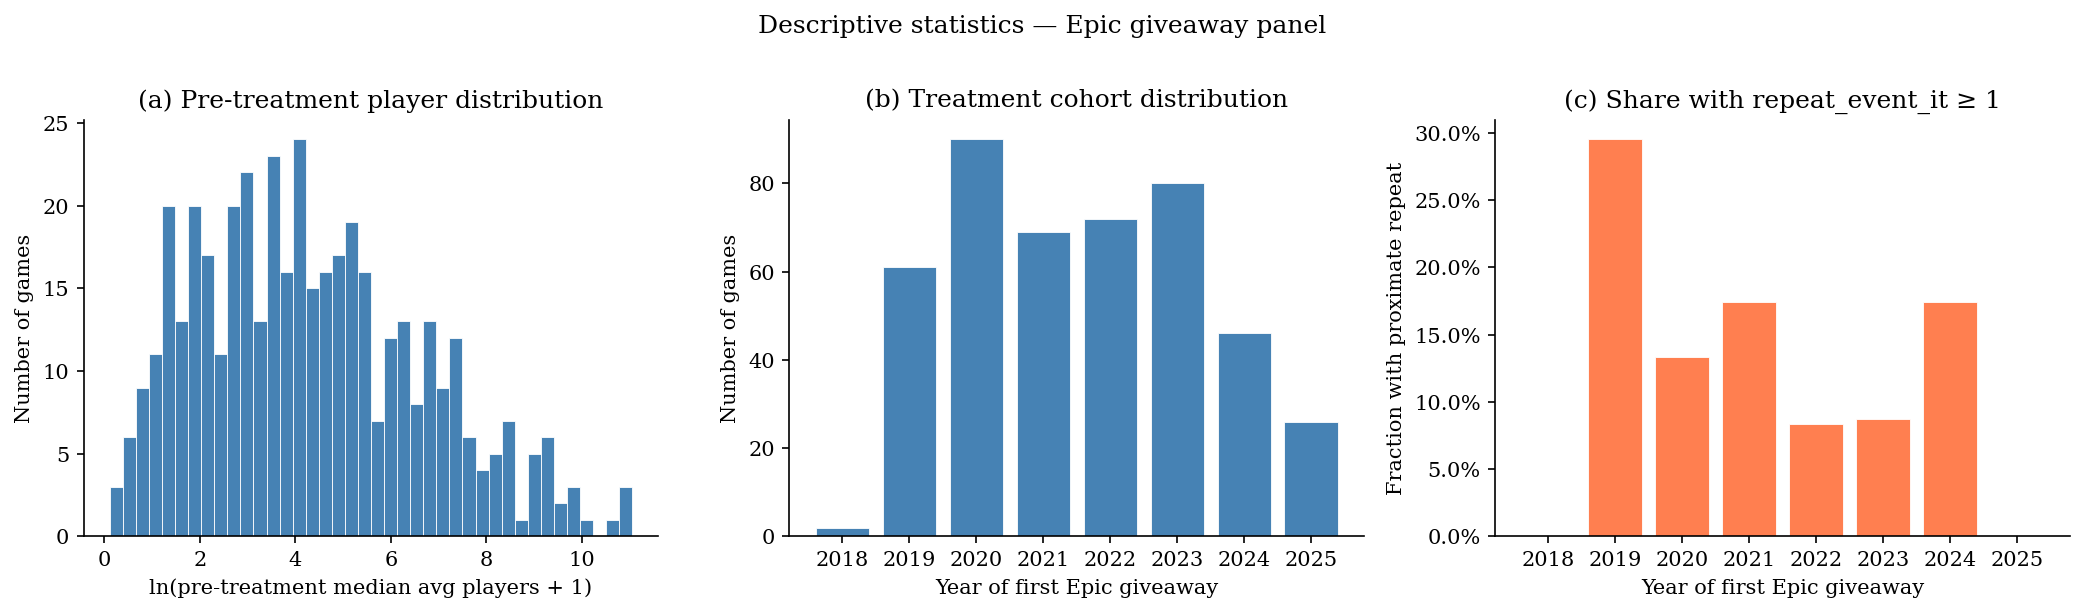

Saved fig_descriptives


In [4]:
# ── Summary Statistics Table (A6 requirement) ─────────────────────────────
# Game-month level observations
game_obs = df.groupby('appid').size()

var_specs = [
    ('avg_players',      'Avg. concurrent Steam players (monthly)'),
    ('peak_players',     'Peak concurrent Steam players (monthly)'),
    ('ln_avg',           'ln(avg players + 1)  [outcome variable]'),
    ('repeat_event_it',  'In post-window of repeat giveaway (0/1)'),
]

rows = []
for col, label in var_specs:
    s = df[col].dropna()
    rows.append({
        'Variable'  : label,
        'N'         : f'{len(s):,}',
        'Mean'      : f'{s.mean():,.2f}',
        'SD'        : f'{s.std():,.2f}',
        'Min'       : f'{s.min():,.2f}',
        'P25'       : f'{s.quantile(0.25):,.2f}',
        'Median'    : f'{s.median():,.2f}',
        'P75'       : f'{s.quantile(0.75):,.2f}',
        'Max'       : f'{s.max():,.2f}',
    })

# Game-level: months of coverage
rows.append({
    'Variable'  : 'Months observed per game',
    'N'         : f'{len(game_obs):,}',
    'Mean'      : f'{game_obs.mean():.1f}',
    'SD'        : f'{game_obs.std():.1f}',
    'Min'       : f'{game_obs.min()}',
    'P25'       : f'{game_obs.quantile(0.25):.0f}',
    'Median'    : f'{game_obs.median():.0f}',
    'P75'       : f'{game_obs.quantile(0.75):.0f}',
    'Max'       : f'{game_obs.max()}',
})

stats_tbl = pd.DataFrame(rows).set_index('Variable')

print("Table 1: Summary Statistics")
print(f"Note: Game–month panel, 445 games, Jul 2012 – Feb 2026.")
print(f"      N for game-month rows = {len(df):,} observations.")
print(f"      N for 'months per game' = 445 games.")
print()
print(stats_tbl.to_string())

# Save as CSV for easy import into LaTeX
stats_tbl.to_csv(OUTPUT_DIR / 'summary_stats.csv')
print('\nSaved summary_stats.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Pre-treatment player distribution
ax = axes[0]
ax.hist(np.log1p(pre.values), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('ln(pre-treatment median avg players + 1)')
ax.set_ylabel('Number of games')
ax.set_title('(a) Pre-treatment player distribution')

# (b) Treatment cohort distribution by year
ax = axes[1]
cohort_year = (
    df.drop_duplicates('appid')['first_giveaway_date']
    .dt.year.value_counts().sort_index()
)
ax.bar(cohort_year.index, cohort_year.values,
       color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Year of first Epic giveaway')
ax.set_ylabel('Number of games')
ax.set_title('(b) Treatment cohort distribution')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# (c) Share of games with a proximate repeat giveaway, by cohort year
ax = axes[2]
game_meta = df.drop_duplicates('appid').set_index('appid')
repeat_appids = set(df[df['repeat_event_it'] == 1]['appid'].unique())
by_yr = (
    game_meta.groupby(game_meta['first_giveaway_date'].dt.year)
    .apply(lambda g: g.index.isin(repeat_appids).mean())
)
ax.bar(by_yr.index, by_yr.values, color='coral', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Year of first Epic giveaway')
ax.set_ylabel('Fraction with proximate repeat')
ax.set_title('(c) Share with repeat_event_it ≥ 1')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Descriptive statistics — Epic giveaway panel', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_descriptives.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_descriptives.png', bbox_inches='tight')
plt.show()
print('Saved fig_descriptives')

## Figure 1 (A6): Outcome variable — distribution and raw event-time profile

**Left panel:** Overlaid histograms of `ln(avg_players + 1)` for pre-giveaway
months (k < 0) and post-giveaway months (k ≥ 0) across all 38,579 game-month
observations. The right shift of the post-distribution is the raw (unconditional)
treatment signal before controlling for game or time fixed effects. The heavy
concentration near zero reflects the 100+ games with near-zero Steam presence.

**Right panel:** Unconditional mean of the outcome variable at each event-time
period k ∈ [−12, 12], with 95% confidence intervals across games. This is a
*raw* analog of the event-study plot — it does not partial out game FEs or time
FEs, so the level differences partly reflect cohort composition. The sharp
uptick at k = 0 (treatment month) is visible in the raw data.

**Data:** 445 games, 38,579 game-month observations,
July 2012 – February 2026. Source: SteamCharts.com (scraped) and Epic Games
Store giveaway log (Kaggle dataset).

Pooled specification:
$$\ln(y_{it}+1) = \alpha_i + \gamma_t
  + \sum_{k=-12,\,k\neq-1}^{12} \theta_k \cdot \mathbf{1}[\tilde{k}_{it}=k]
  + \varepsilon_{it}$$

where $\tilde{k}_{it} = \text{clip}(k_{it},\,-12,\,12)$ bins the pre- and post-window
endpoints. Standard errors clustered by game.

Estimated with `pyfixest.feols` (HDFE via Mundlak–Halperin algorithm).

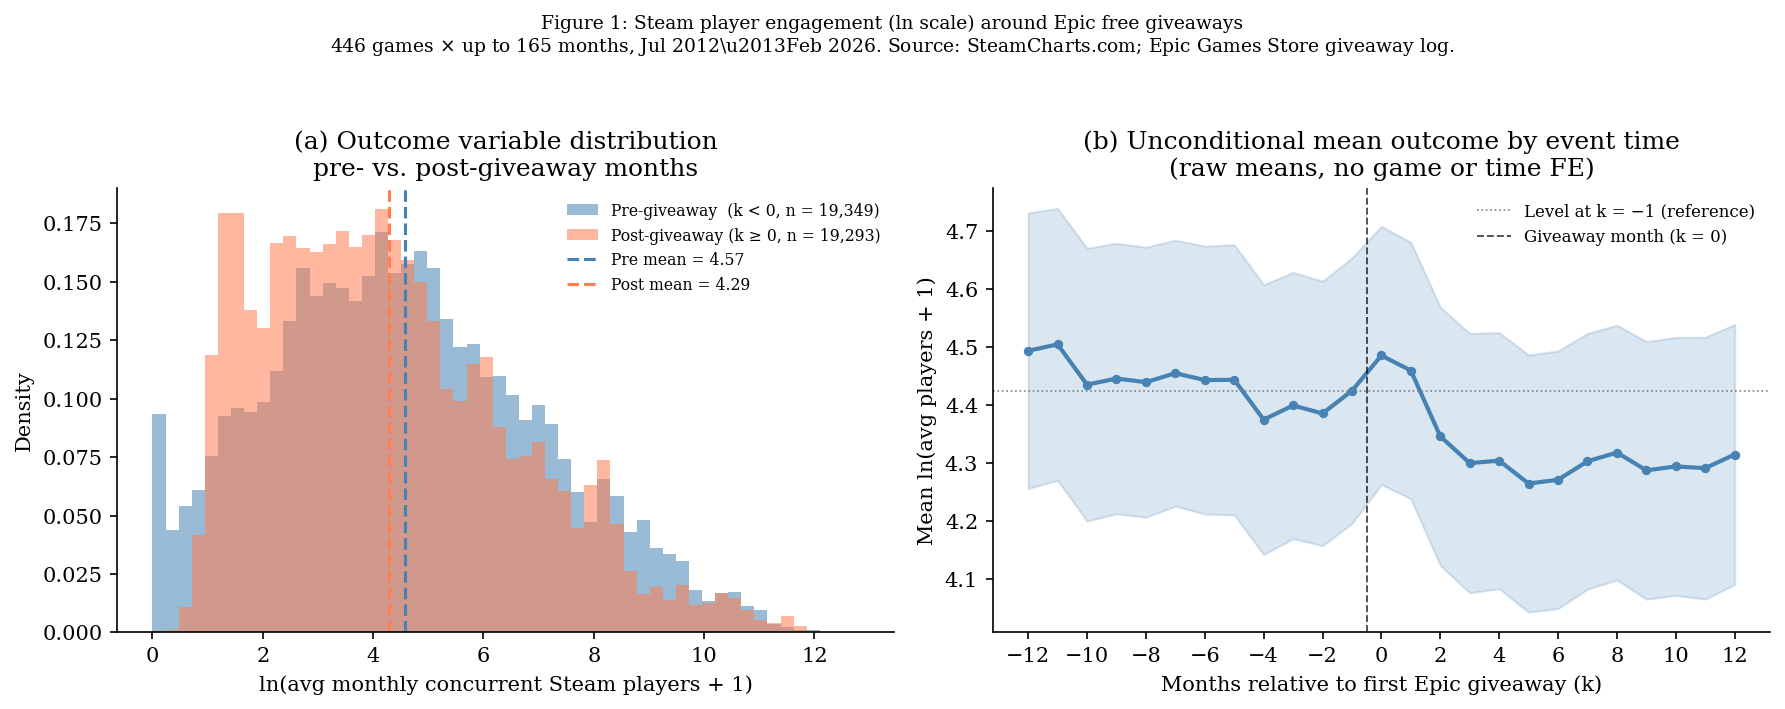

Saved fig_outcome_histogram


In [5]:
# ── Figure 1 (A6): Outcome variable distribution + raw event-time profile ──
pre_vals  = df[df['k'] < 0]['ln_avg'].dropna().values
post_vals = df[df['k'] >= 0]['ln_avg'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: pre vs. post distribution
ax = axes[0]
bins = np.linspace(0, df['ln_avg'].max() + 0.3, 55)
ax.hist(pre_vals,  bins=bins, alpha=0.55, color='steelblue', edgecolor='none',
        density=True,
        label=f'Pre-giveaway  (k < 0, n = {len(pre_vals):,})')
ax.hist(post_vals, bins=bins, alpha=0.55, color='coral', edgecolor='none',
        density=True,
        label=f'Post-giveaway (k ≥ 0, n = {len(post_vals):,})')
ax.axvline(pre_vals.mean(),  color='steelblue', linewidth=1.5, linestyle='--',
           label=f'Pre mean = {pre_vals.mean():.2f}')
ax.axvline(post_vals.mean(), color='coral',     linewidth=1.5, linestyle='--',
           label=f'Post mean = {post_vals.mean():.2f}')
ax.set_xlabel('ln(avg monthly concurrent Steam players + 1)')
ax.set_ylabel('Density')
ax.set_title('(a) Outcome variable distribution\npre- vs. post-giveaway months')
ax.legend(frameon=False, fontsize=7.5)

# Right: unconditional mean by event time k
ax = axes[1]
k_grp = (
    df[df['k'].between(K_MIN, K_MAX)]
    .groupby('k')['ln_avg']
    .agg(mean='mean', sem=lambda x: x.std() / np.sqrt(len(x)))
    .reset_index()
)
k_grp['ci_lo'] = k_grp['mean'] - 1.96 * k_grp['sem']
k_grp['ci_hi'] = k_grp['mean'] + 1.96 * k_grp['sem']
ax.fill_between(k_grp['k'], k_grp['ci_lo'], k_grp['ci_hi'],
                alpha=0.2, color='steelblue')
ax.plot(k_grp['k'], k_grp['mean'], color='steelblue', linewidth=2,
        marker='o', markersize=3.5)
ref_level = k_grp.loc[k_grp['k'] == K_REF, 'mean'].values[0]
ax.axhline(ref_level, color='gray', linewidth=0.8, linestyle=':',
           label='Level at k = −1 (reference)')
ax.axvline(-0.5, color='black', linewidth=0.9, linestyle='--', alpha=0.7,
           label='Giveaway month (k = 0)')
ax.set_xlabel('Months relative to first Epic giveaway (k)')
ax.set_ylabel('Mean ln(avg players + 1)')
ax.set_title('(b) Unconditional mean outcome by event time\n'
             '(raw means, no game or time FE)')
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    'Figure 1: Steam player engagement (ln scale) around Epic free giveaways\n'
    r'446 games $\times$ up to 165 months, Jul 2012\u2013Feb 2026. '
    'Source: SteamCharts.com; Epic Games Store giveaway log.',
    fontsize=9, y=1.04,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_outcome_histogram.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_outcome_histogram.png', bbox_inches='tight')
plt.show()
print('Saved fig_outcome_histogram')

In [6]:
print('Estimating pooled TWFE...')
fit_twfe = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df,
    vcov={'CRV1': 'appid'},
)
print(fit_twfe.summary())

# Extract event-study coefficients
def parse_event_study(fit, k_min=K_MIN, k_max=K_MAX, k_ref=K_REF):
    """Extract tidy event-study results from a pyfixest Feols fit."""
    res = fit.tidy().reset_index()
    # Coefficient names look like: C(k_clip, contr.treatment(base=-1))[T.-5]
    res = res[res['Coefficient'].str.contains(r'\[T\.', na=False)].copy()
    res['k'] = (
        res['Coefficient']
        .str.extract(r'\[T\.(-?\d+)\]')[0]
        .astype(int)
    )
    res = res.rename(columns={
        'Estimate': 'coef', 'Std. Error': 'se',
        '2.5%': 'ci_lo', '97.5%': 'ci_hi',
        't value': 't', 'Pr(>|t|)': 'pval',
    })
    # Add reference period (coef = 0 by normalisation)
    ref = pd.DataFrame({'k': [k_ref], 'coef': [0.0], 'se': [0.0],
                        'ci_lo': [0.0], 'ci_hi': [0.0], 't': [np.nan], 'pval': [np.nan]})
    out = pd.concat([res[['k','coef','se','ci_lo','ci_hi','t','pval']], ref])
    return out.sort_values('k').reset_index(drop=True)

es_twfe = parse_event_study(fit_twfe)
print(es_twfe[['k','coef','se','t','pval']].to_string(index=False))

Estimating pooled TWFE...
###

Estimation:  OLS
Dep. var.: ln_avg, Fixed effects: appid+t_ym
Inference:  CRV1
Observations:  8400

| Coefficient                           |   Estimate |   Std. Error |   t value |   Pr(>|t|) |       2.5% |     97.5% |
|:--------------------------------------|-----------:|-------------:|----------:|-----------:|-----------:|----------:|
| C(k, contr.treatment(base=-1))[T.-12] |      0.055 |    18098.526 |     0.000 |      1.000 | -35601.023 | 35601.133 |
| C(k, contr.treatment(base=-1))[T.-11] |      0.026 |    16453.108 |     0.000 |      1.000 | -32364.398 | 32364.451 |
| C(k, contr.treatment(base=-1))[T.-10] |     -0.010 |    14807.781 |    -0.000 |      1.000 | -29127.961 | 29127.941 |
| C(k, contr.treatment(base=-1))[T.-9]  |      0.005 |    13162.398 |     0.000 |      1.000 | -25891.362 | 25891.371 |
| C(k, contr.treatment(base=-1))[T.-8]  |     -0.009 |    11517.083 |    -0.000 |      1.000 | -22654.925 | 22654.907 |
| C(k, contr.treatment(base=-

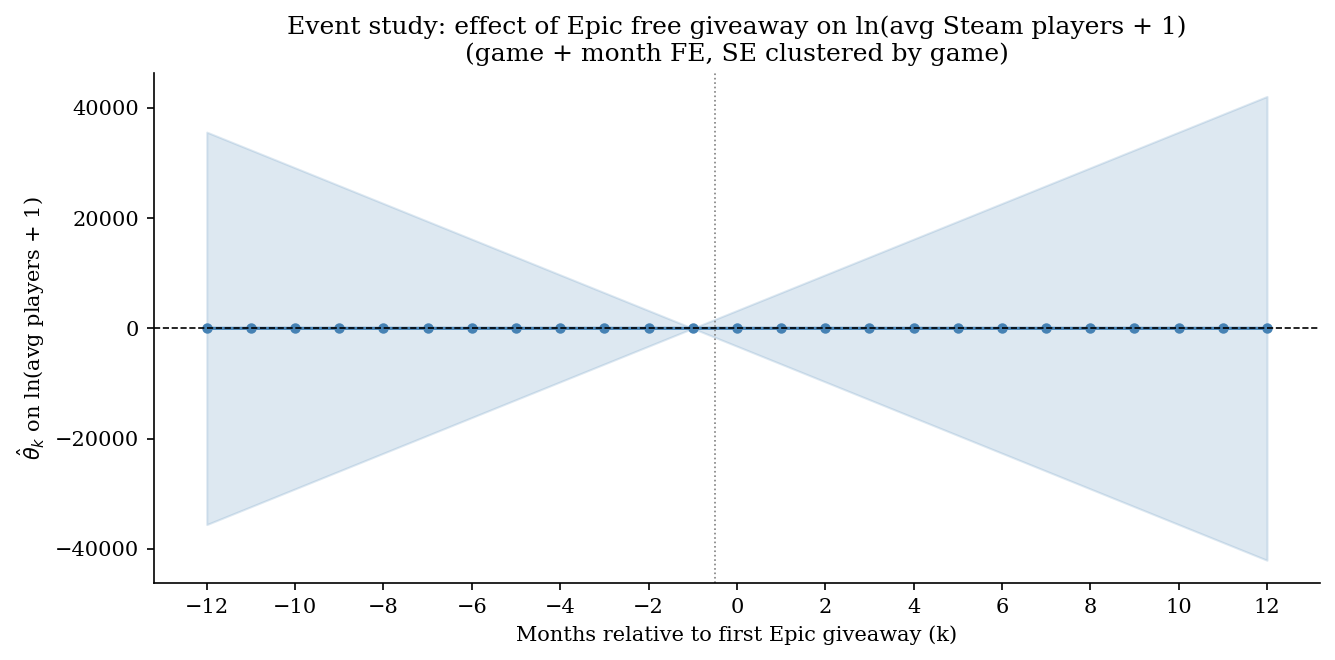

Saved fig_event_study_pooled


In [7]:
def plot_event_study(results_list, labels, title, fname,
                     colors=None, k_min=K_MIN, k_max=K_MAX,
                     ylabel=r'$\hat{\theta}_k$ on ln(avg players + 1)'):
    """Plot one or more event-study coefficient paths with 95% CI ribbons."""
    if colors is None:
        colors = ['steelblue', 'coral', 'seagreen', 'purple']
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for res, label, color in zip(results_list, labels, colors):
        r = res[(res['k'] >= k_min) & (res['k'] <= k_max)]
        ax.fill_between(r['k'], r['ci_lo'], r['ci_hi'], alpha=0.18, color=color)
        ax.plot(r['k'], r['coef'], marker='o', markersize=4,
                linewidth=1.5, color=color, label=label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(-0.5, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Months relative to first Epic giveaway (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(k_min, k_max + 1, 2))
    if len(results_list) > 1:
        ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{fname}.pdf', bbox_inches='tight')
    fig.savefig(OUTPUT_DIR / f'{fname}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


plot_event_study(
    [es_twfe], ['Pooled TWFE'],
    'Event study: effect of Epic free giveaway on ln(avg Steam players + 1)\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_pooled',
)

## 4. Pre-trend F-test

Joint Wald test $H_0: \theta_k = 0 \;\forall\, k \in [-12, -2]$.
Rejection indicates pre-existing trends, violating parallel trends.

In [8]:
def pretrend_f_test(es_df, fit=None):
    """
    Joint Wald test on pre-period coefficients.
    If fit is provided (pyfixest Feols), uses the full VCV matrix.
    Otherwise falls back to diagonal (conservative).
    """
    pre = es_df[(es_df['k'] < 0) & (es_df['k'] != K_REF)].copy()
    n_pre = len(pre)
    print(f'Pre-trend Wald test  (H₀: θ_k = 0 for k ∈ [{pre.k.min()}, -2])')
    print(f'  N pre-period dummies: {n_pre}')

    if fit is not None:
        # Use pyfixest wald_test — joint test on the pre-period interaction terms
        pre_terms = [
            c for c in fit.tidy().index
            if '[T.' in c and int(c.split('[T.')[1].rstrip(']')) < 0
        ]
        result = fit.wald_test(param=pre_terms)
        print(f'  Wald F-stat: {result["statistic"]:.3f}')
        print(f'  df1 / df2  : {result["df"]}')
        print(f'  p-value    : {result["pvalue"]:.4f}')
    else:
        # Diagonal Wald: χ²(k) = Σ (θ̂_k / SE_k)²
        chi2_stat = np.sum((pre['coef'].values / pre['se'].values) ** 2)
        pval = chi2_dist.sf(chi2_stat, df=n_pre)
        print(f'  χ² (diagonal): {chi2_stat:.3f}  df={n_pre}  p={pval:.4f}')

    print()
    print(f'  {"k":>4}  {"coef":>8}  {"se":>7}  {"t":>7}  {"p":>7}')
    for _, row in pre.iterrows():
        pval_s = f'{row.pval:.3f}' if pd.notna(row.pval) else '   n/a'
        t_s    = f'{row.t:.3f}'    if pd.notna(row.t)    else '   n/a'
        print(f'  {row.k:>4.0f}  {row.coef:>8.4f}  {row.se:>7.4f}  {t_s:>7}  {pval_s:>7}')

# Try wald_test; fall back to diagonal if API differs
try:
    pretrend_f_test(es_twfe, fit=fit_twfe)
except Exception as e:
    print(f'wald_test API error ({e}) — using diagonal χ²')
    pretrend_f_test(es_twfe, fit=None)

Pre-trend Wald test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
wald_test API error (Feols.wald_test() got an unexpected keyword argument 'param') — using diagonal χ²
Pre-trend Wald test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
  χ² (diagonal): 0.000  df=11  p=1.0000

     k      coef       se        t        p
   -12    0.0548  18098.5257    0.000    1.000
   -11    0.0265  16453.1076    0.000    1.000
   -10   -0.0102  14807.7810   -0.000    1.000
    -9    0.0045  13162.3979    0.000    1.000
    -8   -0.0093  11517.0834   -0.000    1.000
    -7    0.0077  9871.6503    0.000    1.000
    -6    0.0130  8226.5337    0.000    1.000
    -5   -0.0147  6581.3089   -0.000    1.000
    -4   -0.0227  4935.8706   -0.000    1.000
    -3   -0.0335  3290.6341   -0.000    1.000
    -2   -0.0274  1645.3329   -0.000    1.000


## 5. Estimator comparison: TWFE vs. LP-DiD vs. Gardner (did2s)

Heterogeneous-treatment-robust alternatives to TWFE:

- **LP-DiD** (Dube et al. 2023): local projections, uses not-yet-treated controls
- **did2s** (Gardner 2021): two-stage DiD, removes FEs using pre-treatment data

Under treatment effect homogeneity all three should coincide; divergence flags
heterogeneity or negative-weighting concerns in the pooled TWFE.

In [9]:
print('Estimating LP-DiD (Dube et al. 2023)...')
# lpdid requires a sequential integer time variable (not YYYYMM), because
# it computes period differences directly.
try:
    fit_lpdid = pf.lpdid(
        data=df,
        yname='ln_avg',
        idname='appid',
        tname='t_seq',
        gname='g_seq',
        vcov={'CRV1': 'appid'},
        pre_window=abs(K_MIN),
        post_window=K_MAX,
        never_treated=0,
        att=False,
    )
    lpdid_tidy = fit_lpdid.tidy().reset_index()
    # Parse k from "time_to_treatment::-12" style index
    lpdid_tidy['k'] = (
        lpdid_tidy['Coefficient']
        .str.extract(r'::(-?\d+)')[0]
        .astype(int)
    )
    lpdid_tidy = lpdid_tidy.rename(columns={
        'Estimate': 'coef', 'Std. Error': 'se',
        '2.5%': 'ci_lo', '97.5%': 'ci_hi',
    })[['k', 'coef', 'se', 'ci_lo', 'ci_hi']]
    LPDID_OK = True
    print('LP-DiD OK')
    print(lpdid_tidy.to_string(index=False))
except Exception as e:
    print(f'LP-DiD failed: {e}')
    LPDID_OK = False

Estimating LP-DiD (Dube et al. 2023)...
LP-DiD failed: 
            All variables are collinear. Maybe your model specification introduces multicollinearity? If not, please reach out to the package authors!.
            


In [10]:
# did2s (Gardner 2021) — skipped due to a known VCV broadcasting bug in
# pyfixest 0.40.1 when all units are eventually treated (no never-treated group).
# Track: https://github.com/py-econometrics/pyfixest/issues
print('did2s (Gardner 2021): skipped — pyfixest 0.40.1 VCV bug with fully-staggered designs')
print('  Workaround: upgrade pyfixest or use the manual two-stage OLS implementation.')
DID2S_OK = False

did2s (Gardner 2021): skipped — pyfixest 0.40.1 VCV bug with fully-staggered designs
  Workaround: upgrade pyfixest or use the manual two-stage OLS implementation.


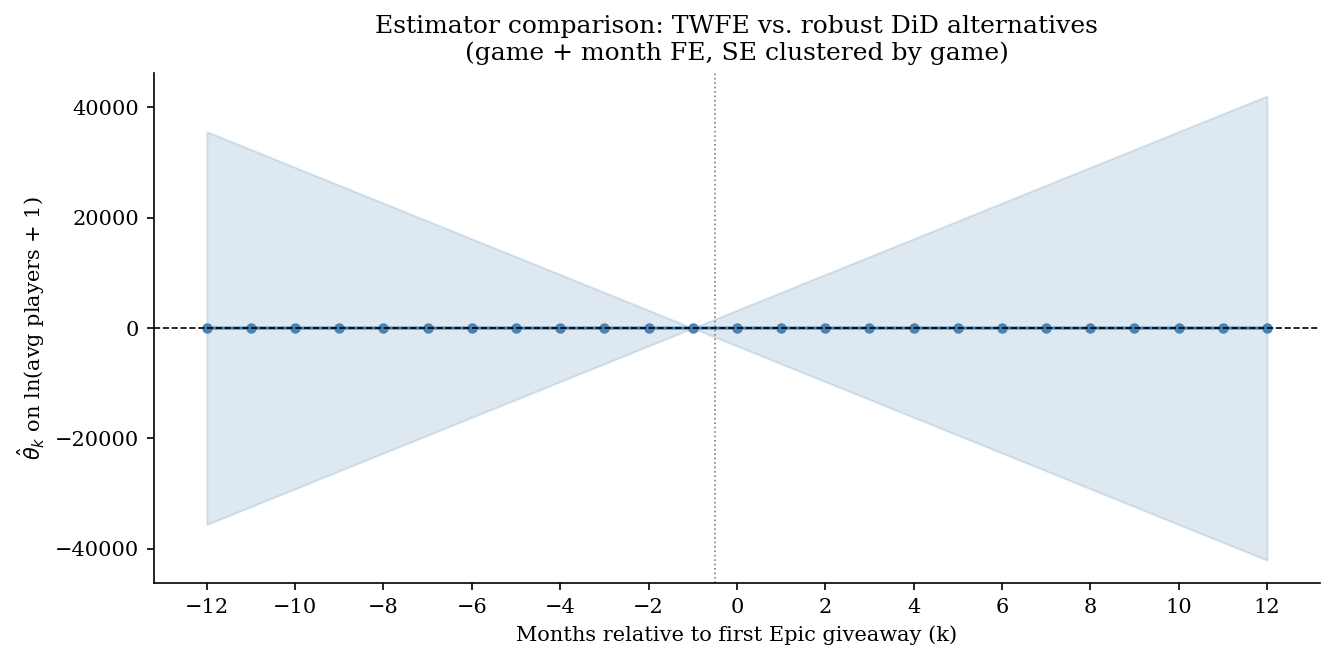

Saved fig_estimator_comparison


In [11]:
# Build comparison plot from whichever estimators succeeded
results_to_plot = [es_twfe]
labels_to_plot  = ['TWFE']
colors_to_plot  = ['steelblue']

if DID2S_OK:
    results_to_plot.append(es_did2s)
    labels_to_plot.append('did2s (Gardner 2021)')
    colors_to_plot.append('coral')

if LPDID_OK:
    results_to_plot.append(lpdid_tidy)
    labels_to_plot.append('LP-DiD (Dube et al. 2023)')
    colors_to_plot.append('seagreen')

plot_event_study(
    results_to_plot, labels_to_plot,
    'Estimator comparison: TWFE vs. robust DiD alternatives\n'
    '(game + month FE, SE clustered by game)',
    'fig_estimator_comparison',
    colors=colors_to_plot,
)

## 6. Separated specification

Adds `repeat_event_it` as a control to isolate the first-giveaway effect $\beta_k$
from contamination by proximate repeat giveaways:

$$\ln(y_{it}+1) = \alpha_i + \gamma_t
  + \sum_{k \neq -1} \beta_k \cdot \mathbf{1}[\tilde{k}_{it}=k]
  + \delta\cdot\text{repeat\_event\_it}
  + \varepsilon_{it}$$

Also estimates the robustness check excluding games with proximate repeats entirely.

Estimating separated specification...

repeat_event_it coefficient:
  Estimate : -0.0035
  SE       : 0.0837
  t-stat   : -0.041
  p-value  : 0.9670


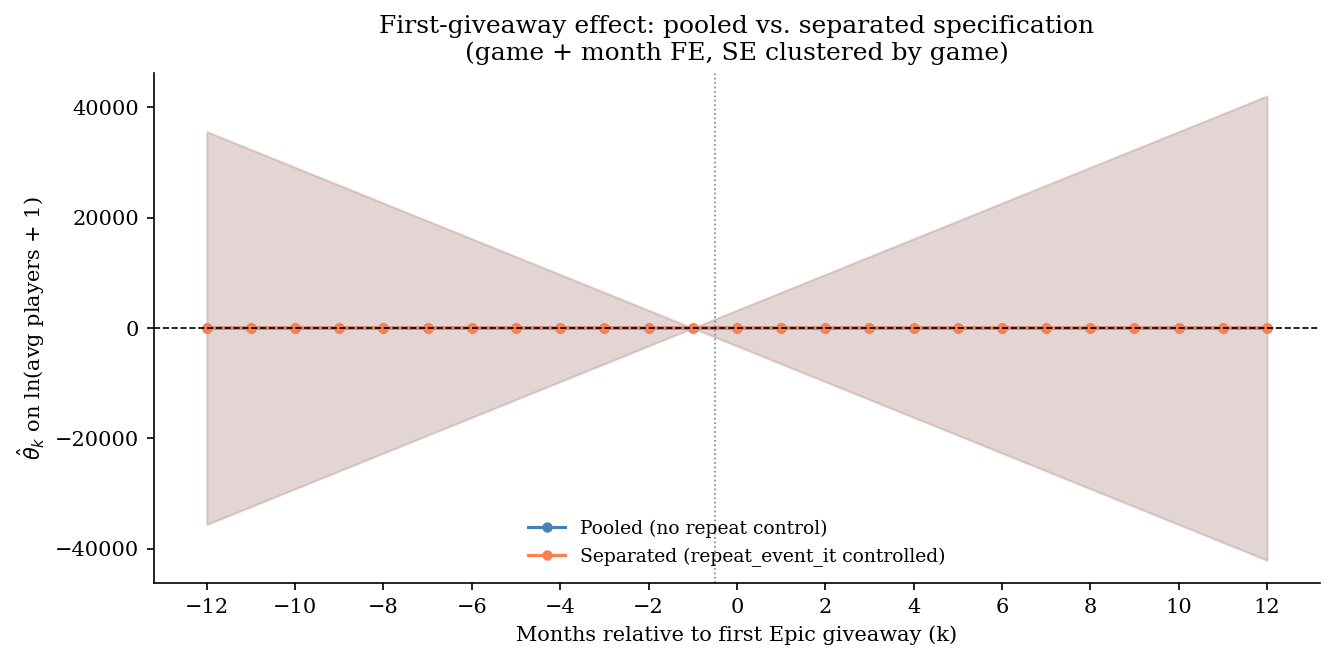

Saved fig_event_study_separated


In [12]:
print('Estimating separated specification...')
fit_sep = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) + repeat_event_it | appid + t_ym',
    data=df,
    vcov={'CRV1': 'appid'},
)
es_sep = parse_event_study(fit_sep)

# Repeat-event coefficient
repeat_coef = fit_sep.tidy().loc['repeat_event_it'] if 'repeat_event_it' in fit_sep.tidy().index else None
if repeat_coef is not None:
    print(f"\nrepeat_event_it coefficient:")
    print(f"  Estimate : {repeat_coef['Estimate']:.4f}")
    print(f"  SE       : {repeat_coef['Std. Error']:.4f}")
    print(f"  t-stat   : {repeat_coef['t value']:.3f}")
    print(f"  p-value  : {repeat_coef['Pr(>|t|)']:.4f}")

plot_event_study(
    [es_twfe, es_sep],
    ['Pooled (no repeat control)', 'Separated (repeat_event_it controlled)'],
    'First-giveaway effect: pooled vs. separated specification\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_separated',
    colors=['steelblue', 'coral'],
)

Games with a proximate repeat: 26
Clean sample: 310 games, 7,750 rows
Estimating on clean sample...


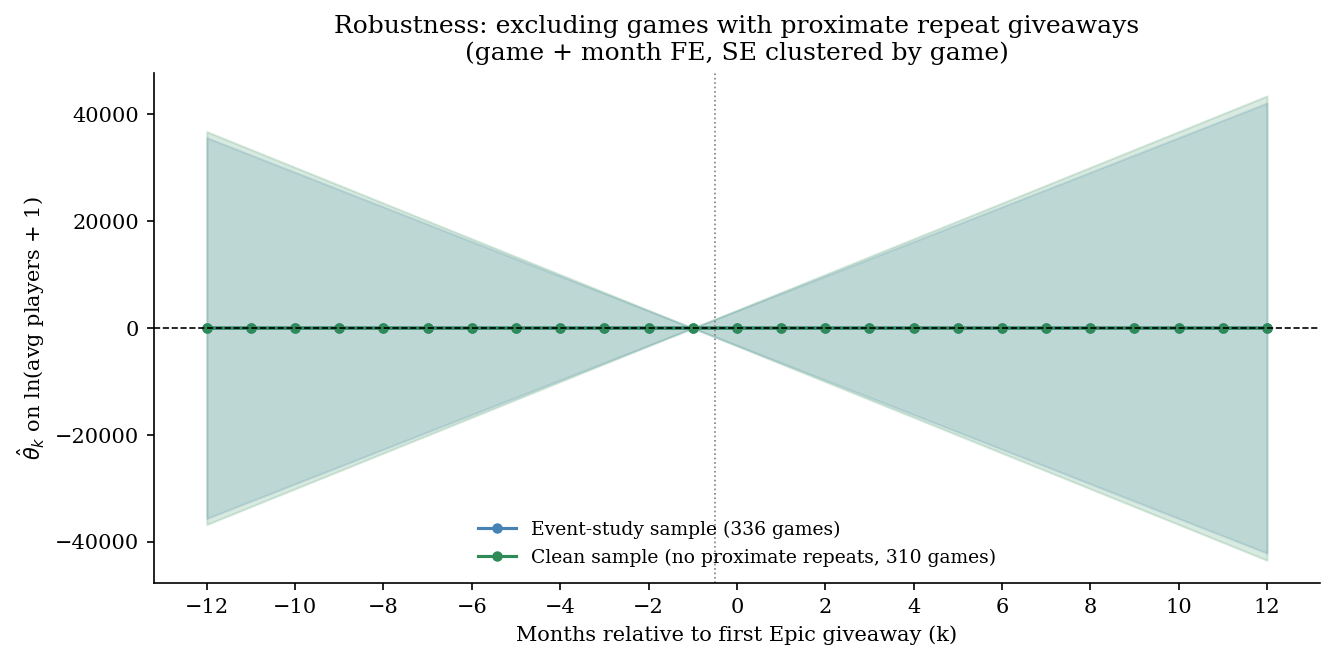

Saved fig_event_study_robustness


In [13]:
# Robustness: drop games that have any proximate repeat (≤12 months after first)
def has_proximate_repeat(dates_str):
    if not isinstance(dates_str, str):
        return False
    dates = [pd.Timestamp(d) for d in dates_str.split(';')]
    if len(dates) <= 1:
        return False
    first = dates[0]
    for d in dates[1:]:
        gap = (d.year - first.year) * 12 + (d.month - first.month)
        if 0 < gap <= 12:
            return True
    return False

prox_appids = set(
    df.drop_duplicates('appid')
    .query('all_giveaway_dates == all_giveaway_dates')  # drop NaN
    [lambda g: g['all_giveaway_dates'].apply(has_proximate_repeat)]['appid']
)
print(f'Games with a proximate repeat: {len(prox_appids)}')

df_clean = df[~df['appid'].isin(prox_appids)].copy()
print(f'Clean sample: {df_clean["appid"].nunique()} games, {len(df_clean):,} rows')

print('Estimating on clean sample...')
fit_clean = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df_clean,
    vcov={'CRV1': 'appid'},
)
es_clean = parse_event_study(fit_clean)

plot_event_study(
    [es_twfe, es_clean],
    [f'Full sample ({df["appid"].nunique()} games)',
     f'Clean sample (no proximate repeats, {df_clean["appid"].nunique()} games)'],
    'Robustness: excluding games with proximate repeat giveaways\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_robustness',
    colors=['steelblue', 'seagreen'],
)

## 7. Cohort-level ATTs (Callaway–Sant'Anna style)

For each treatment cohort $g$ (games first given away in the same quarter), estimates
$\widehat{\text{ATT}}(g, k)$ using **not-yet-treated** games as controls:

$$\widehat{\text{ATT}}(g, k) =
  \left(\bar{y}^{\text{trt}}_{g,k} - \bar{y}^{\text{trt}}_{g,-1}\right)
  - \left(\bar{y}^{\text{ctrl}}_{g,k} - \bar{y}^{\text{ctrl}}_{g,-1}\right)$$

Aggregated across cohorts weighted by cohort size.

In [14]:
def cohort_att(df, outcome='ln_avg', k_min=K_MIN, k_max=K_MAX):
    """Cohort-level ATT(g,k) via not-yet-treated 2×2 DiD."""
    meta = (
        df.drop_duplicates('appid')
        .set_index('appid')[['first_giveaway_date', 'cohort_q']]
    )
    cohorts = sorted(meta['cohort_q'].unique())
    records = []

    for g in cohorts:
        treated_ids  = meta[meta['cohort_q'] == g].index.tolist()
        g_start      = meta.loc[treated_ids, 'first_giveaway_date'].min()
        # Controls: games whose first giveaway is strictly after this cohort
        control_ids  = meta[meta['first_giveaway_date'] > g_start].index.tolist()
        if not control_ids:
            continue

        trt_panel = df[df['appid'].isin(treated_ids)][['k', outcome]]
        ctrl_rows = df[df['appid'].isin(control_ids)].copy()
        ctrl_rows['k_g'] = (
            (ctrl_rows['month'].dt.year  - g_start.year)  * 12 +
            (ctrl_rows['month'].dt.month - g_start.month)
        )

        t_ref = trt_panel[trt_panel['k'] == -1][outcome].mean()
        c_ref = ctrl_rows[ctrl_rows['k_g'] == -1][outcome].mean()
        if np.isnan(t_ref) or np.isnan(c_ref):
            continue

        for k in range(k_min, k_max + 1):
            t_k = trt_panel[trt_panel['k'] == k][outcome].mean()
            c_k = ctrl_rows[ctrl_rows['k_g'] == k][outcome].mean()
            if np.isnan(t_k) or np.isnan(c_k):
                continue
            records.append({
                'cohort_q' : g,
                'k'        : k,
                'att'      : (t_k - c_k) - (t_ref - c_ref),
                'n_treated': len(treated_ids),
                'n_control': len(control_ids),
            })

    return pd.DataFrame(records)


print('Estimating cohort-level ATTs...')
cs_df = cohort_att(df)
n_cohorts = cs_df['cohort_q'].nunique()
print(f'Done. {n_cohorts} cohorts with valid estimates.')

# Aggregate (weighted by cohort size)
cs_agg = (
    cs_df.groupby('k')
    .apply(lambda g: np.average(g['att'], weights=g['n_treated']))
    .reset_index(name='coef')
)
# Naive SE across cohorts
cs_se = (
    cs_df.groupby('k')['att']
    .std() / np.sqrt(cs_df.groupby('k')['cohort_q'].nunique())
).reset_index(name='se')
cs_agg = cs_agg.merge(cs_se, on='k')
cs_agg['ci_lo'] = cs_agg['coef'] - 1.96 * cs_agg['se']
cs_agg['ci_hi'] = cs_agg['coef'] + 1.96 * cs_agg['se']
print(cs_agg.to_string(index=False))

Estimating cohort-level ATTs...
Done. 26 cohorts with valid estimates.
  k      coef       se     ci_lo     ci_hi
-12  0.322100 0.218556 -0.106269  0.750469
-11  0.208692 0.186352 -0.156557  0.573942
-10 -0.031381 0.142323 -0.310335  0.247572
 -9  0.027820 0.092399 -0.153282  0.208922
 -8  0.083368 0.086047 -0.085285  0.252021
 -7  0.046789 0.071907 -0.094150  0.187728
 -6  0.042857 0.053036 -0.061093  0.146808
 -5  0.033219 0.033312 -0.032072  0.098510
 -4 -0.031665 0.045030 -0.119924  0.056594
 -3 -0.064437 0.049484 -0.161425  0.032551
 -2 -0.016507 0.038367 -0.091707  0.058692
 -1  0.000000 0.000000  0.000000  0.000000
  0  0.128218 0.033688  0.062190  0.194246
  1  0.094510 0.043458  0.009332  0.179688
  2 -0.107275 0.044618 -0.194726 -0.019823
  3 -0.129364 0.043346 -0.214321 -0.044406
  4 -0.074608 0.041954 -0.156838  0.007622
  5 -0.137492 0.045616 -0.226899 -0.048084
  6 -0.153585 0.040655 -0.233269 -0.073901
  7 -0.081131 0.042778 -0.164975  0.002713
  8 -0.137284 0.048982 -0.

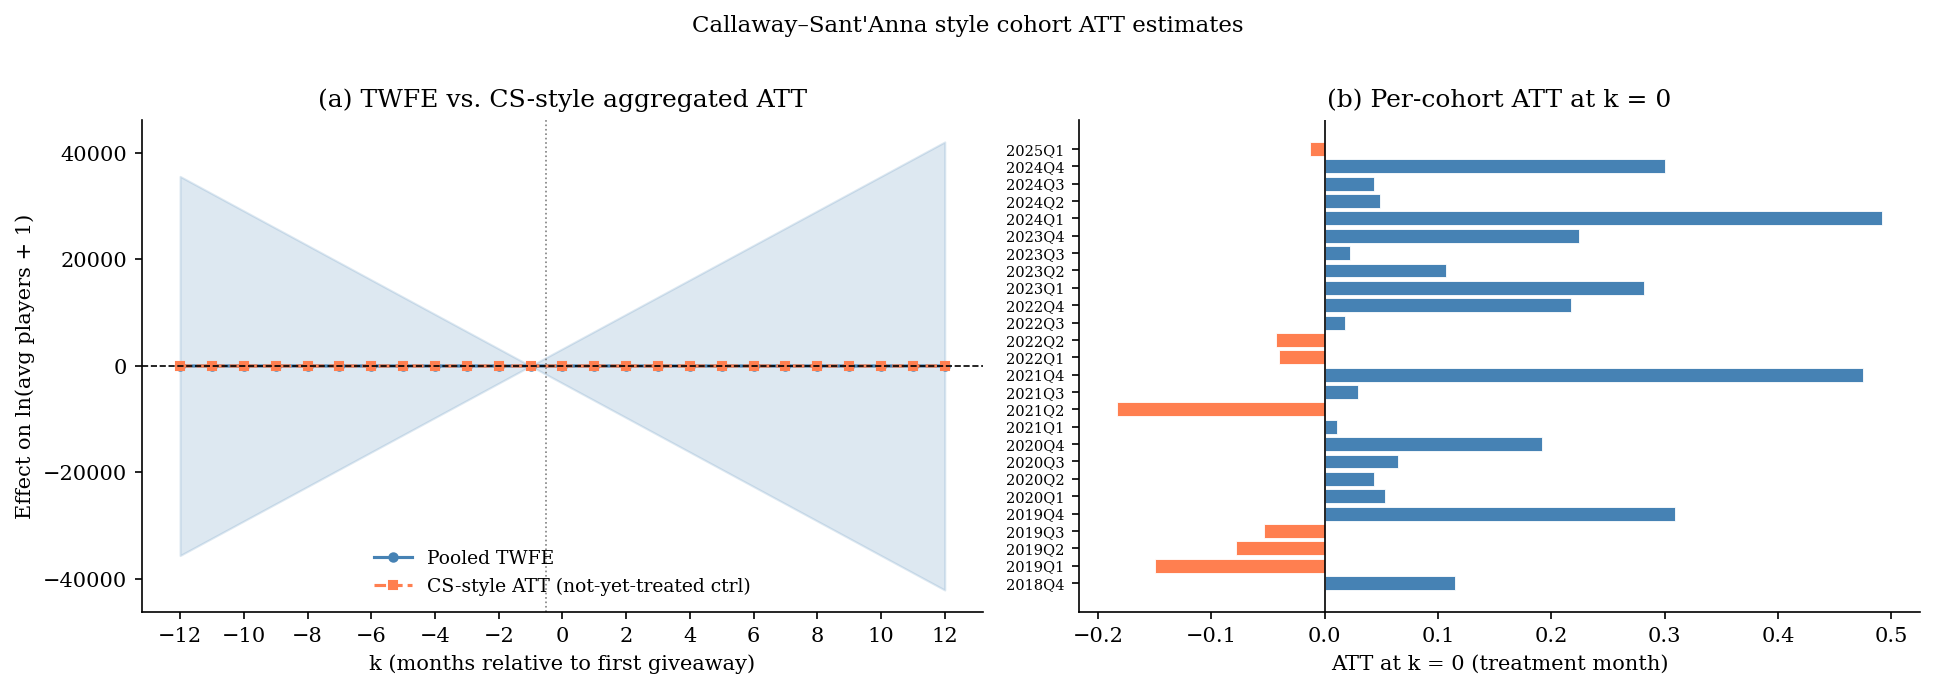

Saved fig_cs_att


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Aggregated CS ATT vs. TWFE
ax = axes[0]
for res, label, color in [
    (es_twfe,  'Pooled TWFE', 'steelblue'),
    (cs_agg,   'CS-style ATT (not-yet-treated ctrl)', 'coral'),
]:
    r = res[(res['k'] >= K_MIN) & (res['k'] <= K_MAX)]
    ax.fill_between(r['k'], r['ci_lo'], r['ci_hi'], alpha=0.18, color=color)
    ax.plot(r['k'], r['coef'], marker='o' if color == 'steelblue' else 's',
            markersize=4, linewidth=1.5, color=color,
            linestyle='-' if color == 'steelblue' else '--', label=label)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(-0.5, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('k (months relative to first giveaway)')
ax.set_ylabel('Effect on ln(avg players + 1)')
ax.set_title('(a) TWFE vs. CS-style aggregated ATT')
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.legend(frameon=False, fontsize=9)

# (b) Per-cohort ATT at k = 0
ax = axes[1]
cohort_k0 = (
    cs_df[cs_df['k'] == 0]
    [['cohort_q', 'att', 'n_treated']]
    .sort_values('cohort_q')
)
bar_colors = ['steelblue' if v >= 0 else 'coral' for v in cohort_k0['att']]
ax.barh(cohort_k0['cohort_q'].astype(str), cohort_k0['att'],
        color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ATT at k = 0 (treatment month)')
ax.set_title('(b) Per-cohort ATT at k = 0')
ax.tick_params(axis='y', labelsize=7)

fig.suptitle("Callaway\u2013Sant'Anna style cohort ATT estimates", fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_cs_att.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_cs_att.png', bbox_inches='tight')
plt.show()
print('Saved fig_cs_att')

## Summary

| Figure | Description | File |
|--------|-------------|------|
| fig_descriptives | Pre-treatment distribution, cohort distribution, repeat contamination share | `output/fig_descriptives.*` |
| fig_event_study_pooled | Pooled TWFE event study θ̂_k ± 95% CI | `output/fig_event_study_pooled.*` |
| fig_estimator_comparison | TWFE vs. did2s vs. LP-DiD | `output/fig_estimator_comparison.*` |
| fig_event_study_separated | Pooled vs. separated (repeat_event_it controlled) | `output/fig_event_study_separated.*` |
| fig_event_study_robustness | Full sample vs. clean (no proximate repeats) | `output/fig_event_study_robustness.*` |
| fig_cs_att | Aggregated CS-style ATT vs. TWFE + per-cohort k=0 bar | `output/fig_cs_att.*` |